<a href="https://colab.research.google.com/github/max-power-126/lab1_FFNN/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from csv import reader
import time
from torch.utils.data import TensorDataset, DataLoader

# Task 1 – Preprocessing

In [57]:

# D= length avg 3,E=max length 4,F=bytes 5,J=inter arrival time 9,K=packet length 10


data = pd.read_csv("dataset_lab_1.csv",encoding="utf-8")
# Modo corretto ed efficiente in pandas per filtrare i valori uguali a 0 nelle colonne desiderate
rawdata_size= data.shape
######################################## Missing and Duplicate #############################

print(f"dati iniziali",data.shape)
#drop NaN

data.dropna(inplace=True)

print(f"dati No NaN",data.shape)

# Definiamo le colonne che non devono contenere zeri
columns_to_filter = [
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Packet Length Mean'
]

# Creiamo una maschera booleana: per ogni riga, tutte le colonne specificate devono essere diverse da 0
# (data[col] != 0).all(axis=1) verifica che la condizione sia True per TUTTE le colonne selezionate


mask = (data[columns_to_filter] != 0.0).all(axis=1)


# Applichiamo la maschera per ottenere il dataset pulito
data_cleaned = data[mask].copy()

modified_size=data_cleaned.shape

print(f"data filtered= {modified_size}")

data_cleaned.drop_duplicates(inplace=True,keep="first")

print(f"data no duplicate= {data_cleaned.shape}")

# Mostriamo la differenza di righe prima e dopo la pulizia

# 1. Rimuoviamo i valori NaN dal dataset finale


# 2. Rimuoviamo i valori infiniti (inf e -inf)
# Selezioniamo solo le colonne numeriche per verificare la presenza di infiniti
numeric_cols = data_cleaned.select_dtypes(include=[np.number]).columns
is_infinite = np.isinf(data_cleaned[numeric_cols]).any(axis=1)

# Teniamo solo le righe che NON contengono infiniti
data_cleaned_final = data_cleaned[~is_infinite]

print(f"data no inf= {data_cleaned_final.shape}")


#############################Encoded######################################

label_encoder = LabelEncoder()
data_cleaned_final['Label'] = label_encoder.fit_transform(data_cleaned_final['Label'])

data_choosed=data_cleaned_final.copy()

########################################### Split #############################

## train = 60 %, validation = 20 % , test=20%

# Split the dataset
X = data_choosed[['Flow Duration', 'Flow IAT Mean', 'Fwd PSH Flags',
       'Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Flow Bytes/s',
       'Down/Up Ratio', 'SYN Flag Count', 'Fwd Packet Length Mean',
       'Fwd IAT Std', 'Packet Length Mean', 'Fwd Packet Length Max',
       'Subflow Fwd Packets', 'Flow Packets/s', 'Total Fwd Packets',
       'Destination Port']].values
y = data_choosed['Label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



#################### Scaling ################################################
# Standardize the features
scaler = StandardScaler()
X_train_S = scaler.fit_transform(X_train)
X_val_S = scaler.transform(X_val)
X_test_S = scaler.transform(X_test)

print(y_train)
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

########################################################################


dati iniziali (31507, 17)
dati No NaN (31487, 17)
data filtered= (23773, 17)
data no duplicate= (23280, 17)
data no inf= (23280, 17)
[2 3 0 ... 0 0 2]


In [58]:
# @title
# fig, ax = plt.subplots(figsize=(10,5))
# plt.scatter(x=data["Feature_1"].values,
#             y=data["Feature_2"].values,
#             c=data["Label"].values,
#             cmap=plt.cm.RdYlBu)
# plt.show()
# plt.close()

# fig, ax = plt.subplots(figsize=(10,5))
# plt.scatter(x=data["Feature_1"].values,
#             y=data["Feature_2"].values,
#             c=data["Label"].values,
#             cmap=plt.cm.RdYlBu)
# plt.xlim(-2,2)
# plt.ylim(-2,2)
# plt.show()
# plt.close()

# Task 2 – Your first network

## Task 2A

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The device is set to: {device}")

The device is set to: cuda


In [60]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-4
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [61]:
# Define the neural network
class ffnn(nn.Module):
    def __init__(self, input_size, output_size):
        super(ffnn, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_width)
        self.fc2 = nn.Linear(hidden_width, output_size)
        self.relu = activation_function()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [62]:
def training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, num_epochs, min_delta = None, patience = None):
  start_time = time.time()

  train_losses = []
  val_losses = []

  best_val_loss = float('inf')
  trigger_times = 0
  best_model_state = None
  for epoch in range(num_epochs):
    train_loss = 0
    val_loss = 0
    model.train()
    for batch_X, batch_y in train_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)
      optimizer.zero_grad()
      outputs = model(batch_X)
      loss = criterion(outputs, batch_y)
      loss.backward()
      optimizer.step()
      train_loss += loss.item() * batch_X.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        val_outputs = model(batch_X)
        loss = criterion(val_outputs, batch_y)
        val_loss += loss.item() * batch_X.size(0)
      val_loss /= len(val_dataset)
      val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
      print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

    if min_delta is not None:
      if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        trigger_times = 0
      else:
        trigger_times += 1
        if trigger_times >= patience:
          print(f"Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.6f})")
          break
    if best_model_state is not None:
      model.load_state_dict(best_model_state)

  end_time = time.time()
  elapsed_time = end_time - start_time
  print(f'The function took {elapsed_time:.4f} seconds to execute.')

  plt.figure(figsize=(10, 5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.show()

  return

In [63]:
def testing_model(model, dataloader, device):
  start_time = time.time()

  model.eval()
  all_labels = []
  all_predictions = []

  with torch.no_grad():
    for inputs, labels in dataloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = torch.max(outputs, 1)
      all_labels.extend(labels.cpu().numpy())
      all_predictions.extend(predicted.cpu().numpy())
  accuracy = accuracy_score(all_labels, all_predictions) * 100

  end_time = time.time()
  elapsed_time = end_time - start_time
  print(f'The function took {elapsed_time:.4f} seconds to execute.')

  return accuracy


In [64]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [65]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 0.0606, Val Loss: 0.0618
Epoch 40/100, Train Loss: 0.0461, Val Loss: 0.0492
Epoch 60/100, Train Loss: 0.0379, Val Loss: 0.0418
Epoch 80/100, Train Loss: 0.0326, Val Loss: 0.0379
Epoch 100/100, Train Loss: 0.0292, Val Loss: 0.0348
The function took 45.1884 seconds to execute.


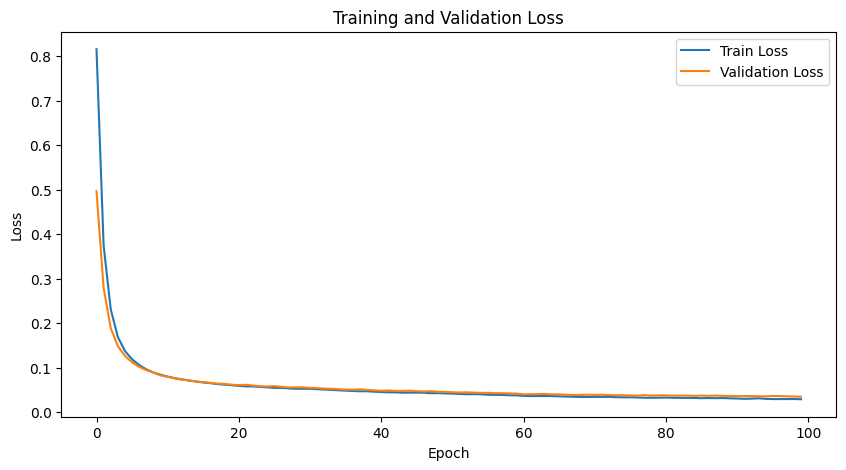

In [66]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [67]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.0058, -0.0248, -0.0961,  ...,  0.4039, -0.0074, -0.1136],
        [-0.0135,  0.1980,  0.0169,  ...,  0.3012,  0.0292,  0.0994],
        [ 0.2599,  0.0959,  0.1976,  ...,  0.4321,  0.1686,  0.1951],
        ...,
        [ 0.2807,  0.0158, -0.0080,  ..., -1.0880, -0.5520,  0.0189],
        [ 0.5731,  0.1481, -0.2584,  ...,  0.0846,  0.0375,  0.2888],
        [ 0.1780, -0.0392, -0.0057,  ..., -1.2416,  0.3183, -0.3836]],
       device='cuda:0')
Learned biases: tensor([ 0.1178, -0.3458, -0.1409, -0.2754,  0.2704,  0.2950,  0.1359, -0.2002,
        -0.0384,  0.1406,  0.3091, -0.3200,  0.2254,  0.3845, -0.0512, -0.0403,
         0.1936, -0.1216,  0.0305,  0.2776,  0.1236,  0.2097,  0.0802,  0.1692,
        -0.0559, -0.0236,  0.1985,  0.3393, -0.1288,  0.5181,  0.1220, -0.2280,
         0.2785,  0.1011, -0.0567,  0.0457,  0.1468, -0.2047,  0.5350, -0.3277,
        -0.1513,  0.2578,  0.0969,  0.2958, -0.2753,  0.3451, -0.1309,  0.0794,
        -0.1564,  0.0672, -0.

In [68]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.1728 seconds to execute.
The function took 0.0707 seconds to execute.
The function took 0.0559 seconds to execute.
Train Accuracy: 99.2626
Validation Accuracy: 99.2053
Test Accuracy: 99.1624


## Task 2B

### S1 – no feature scaling

In [69]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-4
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [70]:
# Convert data to PyTorch tensors and send to CUDA
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

In [71]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [72]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 3280.6484, Val Loss: 2409.2822
Early stopping at epoch 39 (best val loss: 601.684305)
The function took 17.5377 seconds to execute.


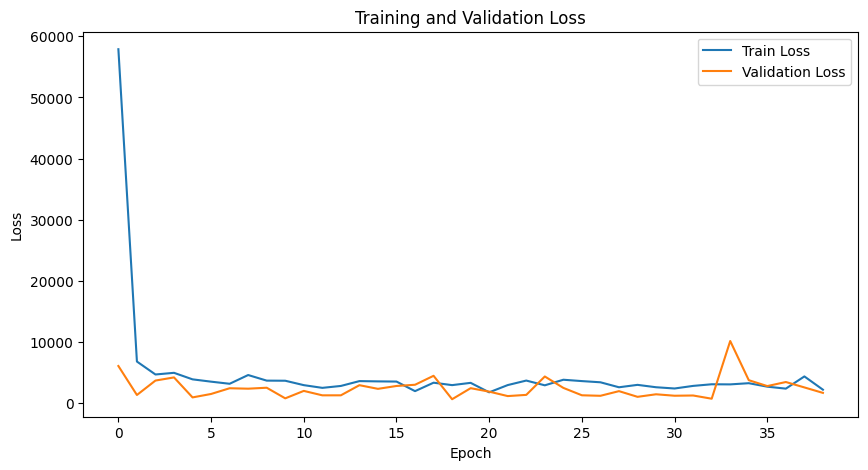

In [73]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [74]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[-0.0453,  0.0315,  0.1042,  ...,  0.0385,  0.4737,  0.3750],
        [ 0.1468, -0.1919,  0.4280,  ..., -0.0779,  0.1898,  0.0529],
        [ 0.2219, -0.0034,  0.1368,  ..., -0.2036, -0.2482,  0.1761],
        ...,
        [-0.0018,  0.2173, -0.0263,  ...,  0.0343, -0.0656, -0.0970],
        [-0.1443, -0.1303, -0.0801,  ..., -0.0065,  0.0852, -0.1730],
        [ 0.1998, -0.2244,  0.1723,  ..., -0.0423,  0.0092,  0.0233]],
       device='cuda:0')
Learned biases: tensor([ 0.2898,  0.0169,  0.1981, -0.1600,  0.0871, -0.2602,  0.1431,  0.3724,
         0.3506, -0.3305, -0.0850,  0.4930, -0.2933,  0.3276,  0.1917, -0.2247,
        -0.1363,  0.1356, -0.2402, -0.0656, -0.2645,  0.4255, -0.2727,  0.1864,
        -0.0758,  0.0111, -0.0343, -0.4127,  0.0887,  0.0113, -0.2407, -0.3344,
        -0.2778,  0.1634,  0.1326, -0.1906,  0.2501, -0.4040, -0.1512, -0.4596,
         0.0527,  0.1594,  0.0582, -0.1107, -0.0139, -0.0358,  0.1227,  0.0180,
        -0.1004, -0.0182, -0.

In [75]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.2661 seconds to execute.
The function took 0.0806 seconds to execute.
The function took 0.0836 seconds to execute.
Train Accuracy: 94.4301
Validation Accuracy: 94.2010
Test Accuracy: 94.6735


###  S2 – far too high learning rate

In [76]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-3 # <-------
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [77]:
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [78]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [79]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 0.0298, Val Loss: 0.0307
Early stopping at epoch 34 (best val loss: 0.030153)
The function took 15.2220 seconds to execute.


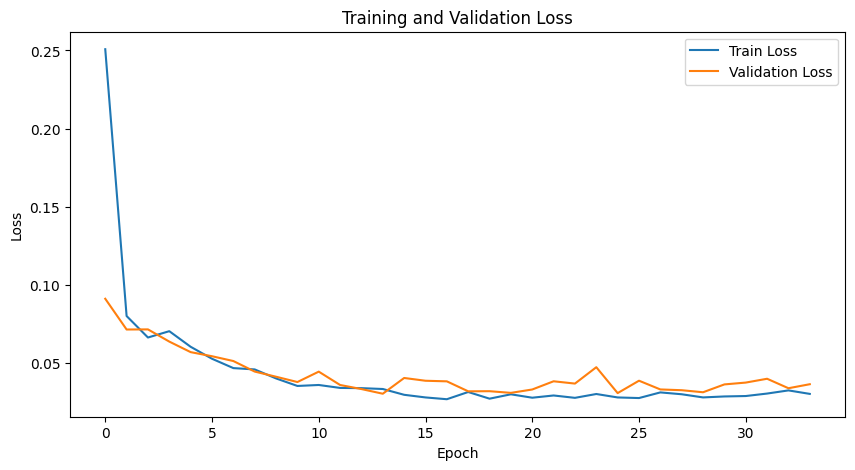

In [80]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [81]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.3333,  0.1127,  0.0405,  ..., -0.1041,  0.9419,  0.1645],
        [-0.0149,  0.1165, -0.4247,  ..., -0.3169, -0.7853,  0.2530],
        [-0.2071,  0.1324,  0.1264,  ...,  0.2096, -1.2129, -0.6825],
        ...,
        [ 0.1658, -0.0471, -0.2263,  ..., -1.4506,  0.3532, -0.3315],
        [ 0.3447,  0.3040,  0.2937,  ..., -0.1020, -0.1854,  0.2982],
        [ 1.0105,  0.2551,  0.0838,  ..., -0.5277, -0.6717, -0.2594]],
       device='cuda:0')
Learned biases: tensor([ 0.0678,  0.2981, -0.4817,  0.2019,  0.1792, -0.3089,  0.4673, -0.2234,
         0.3042,  0.1491,  0.2370,  0.1044,  0.1230,  0.4706,  0.2854,  0.2412,
        -0.1403, -0.3030,  0.0824,  0.5539,  0.0341,  0.0596, -0.0493,  0.2075,
        -0.7034, -0.4403, -0.1383,  0.2687,  0.4976,  0.5692,  0.0986,  0.2862,
        -0.3262, -0.1575,  0.4999, -0.2416, -0.5274, -0.2907,  0.3106,  0.0315,
         0.1304,  0.1390,  0.0832, -0.6580,  0.2222, -0.3750,  0.2168,  0.0406,
         0.5859,  0.2021,  0.

In [82]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.1692 seconds to execute.
The function took 0.0592 seconds to execute.
The function took 0.0541 seconds to execute.
Train Accuracy: 99.2912
Validation Accuracy: 99.2698
Test Accuracy: 99.2053


###  S3 – learning rate far too low

In [83]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-7 # <-------
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [84]:
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [85]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [86]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 1.4055, Val Loss: 1.4063
Epoch 40/100, Train Loss: 1.3640, Val Loss: 1.3650
Epoch 60/100, Train Loss: 1.3237, Val Loss: 1.3249
Epoch 80/100, Train Loss: 1.2847, Val Loss: 1.2860
Epoch 100/100, Train Loss: 1.2468, Val Loss: 1.2483
The function took 51.2674 seconds to execute.


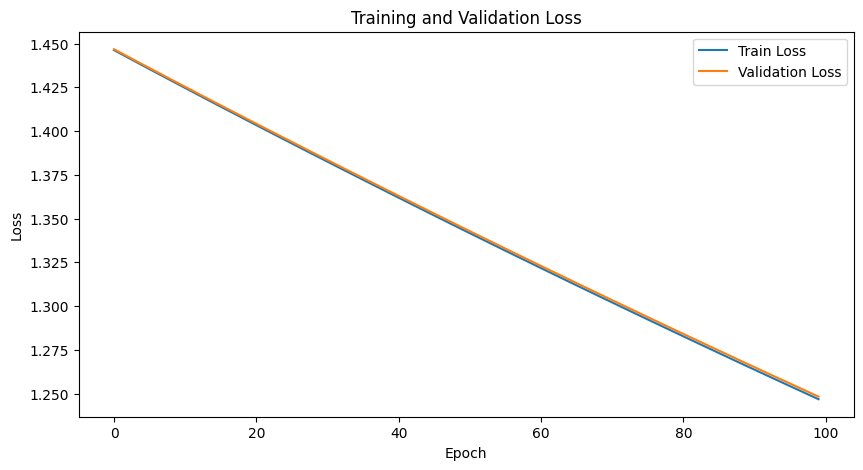

In [87]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [88]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.1316,  0.0199, -0.2484,  ..., -0.1144, -0.0609, -0.1158],
        [ 0.1994, -0.1851,  0.1194,  ...,  0.1845, -0.0110, -0.1506],
        [-0.1262, -0.0275, -0.0097,  ..., -0.0795,  0.0506,  0.1671],
        ...,
        [ 0.2101, -0.1825, -0.1293,  ...,  0.1504,  0.0049, -0.1728],
        [-0.0828,  0.2063, -0.0709,  ..., -0.0116,  0.1146,  0.0271],
        [ 0.0855, -0.0963, -0.0153,  ...,  0.0115, -0.1869, -0.0736]],
       device='cuda:0')
Learned biases: tensor([-1.3581e-01,  2.1201e-01, -2.3980e-01,  3.8805e-02, -2.0982e-01,
         1.5202e-01, -2.5362e-02, -2.1047e-01, -3.2977e-04, -3.9162e-02,
         2.3097e-01,  3.9412e-02, -1.4809e-01,  1.4917e-01,  1.6467e-01,
        -1.2187e-01,  2.6068e-01,  2.5835e-02, -1.7473e-01,  1.3120e-01,
         1.5101e-02,  1.4703e-01, -1.1586e-01,  8.4115e-02, -1.0300e-01,
         1.3028e-01,  5.9796e-02,  1.6678e-01,  1.2793e-01,  9.2219e-02,
        -1.3714e-01,  8.3659e-02,  6.2514e-02,  2.3322e-01,  1.0994e-01

In [89]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.1693 seconds to execute.
The function took 0.0662 seconds to execute.
The function took 0.0573 seconds to execute.
Train Accuracy: 70.2606
Validation Accuracy: 69.8024
Test Accuracy: 69.9957


# Task 3 – When a feature biases the model

In [95]:
X_test[X_test[:,-1] == 80, -1] = 8080